Seismic Signal Classification: 3-Component ResNet
Phase: Training & Hyperparameter Tuning
This notebook implements a Deep Learning pipeline using a Residual Network (ResNet) architecture to classify 3-component seismic signals. The goal is to identify specific seismic events by processing the X, Y, and Z components of the raw data.

1. Prerequisites & Environment Setup
To run this code successfully, ensure you have the following libraries installed:

Data Handling: numpy, pandas

Deep Learning: tensorflow (v2.x), keras-tuner

Preprocessing: scikit-learn, imbalanced-learn (for SMOTE)

Visualization: matplotlib, seaborn

Required Files:
The script expects three pickle files in the working directory:

tr_No_Fil.pkl (Training set)

te_No_Fil.pkl (Test set)

val_No_Fil.pkl (Validation set)

2. Data Pipeline & Preprocessing
The preprocessing stage is critical for ensuring data integrity and model performance:

Restructuring: The restructure_dataframe_3 function flattens the 3-component (X, Y, Z) data into a unified format suitable for a 1D Convolutional Neural Network.

Data Leakage Prevention: A robust hashing mechanism is used to:

Remove internal duplicates within each set.

Ensure no overlapping records exist between Training, Validation, and Testing sets (Priority: Test > Val > Train).

Class Balancing: Since seismic datasets are often imbalanced, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data to prevent the model from biasing toward the majority class.

3. Model Architecture (ResNet 1D)
The model utilizes a Residual Network approach to handle the vanishing gradient problem in deep temporal data.

Residual Blocks: Each block consists of two Conv1D layers with a "shortcut" connection that adds the input back to the output. This allows the network to learn identity mappings and improves training stability.

Hyperparameter Tuning: Instead of fixed values, we use KerasTuner (Hyperband) to automatically find the optimal:

Number of Kernels (Filters)

Stride length

Dense units

Learning Rate

4. Training Strategy
The pipeline follows a two-stage training process:

Optimization: Runs a fast search for hyperparameters using the Hyperband algorithm with early stopping.

Full Training: Takes the best-found parameters and trains the model for up to 150 epochs, saving only the best weights based on validation loss.

5. Evaluation and Export
Once training is complete, the model's performance is visualized through:

Confusion Matrices: Generated for both the training and test sets to observe Type I and Type II errors.

Metric Logging: Final accuracy is printed, and the best model is exported as an .h5 file.

Hyperparameter Logging: The winning configuration is saved as a .json file for future reproducibility.

6. Execution Instructions
Set the Path: Update SAVE_PATH in the configuration section to your desired local directory.

Check Data: Ensure your .pkl files are in the same folder as the notebook.

Run All: Execute the cells sequentially. The tuning phase may take significant time depending on your GPU/CPU capabilities.

In [ ]:
# Seismic Signal Classification - 3 Component ResNet
# Phase: Training & Hyperparameter Tuning


import os
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kerastuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn import metrics
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION & DATA LOADING ---
RECL = 65536  # Signal length
SAVE_PATH = r'C:\Users\researcher\Documents\AMN\USU_seismic\Update_64\resnet'

def load_and_preprocess():
    tr = pd.read_pickle('tr_No_Fil.pkl')
    te = pd.read_pickle('te_No_Fil.pkl')
    val = pd.read_pickle('val_No_Fil.pkl')
    return tr, te, val

def restructure_dataframe_3(df):
    """Consolidates X, Y, and Z components into a single column for training."""
    components = []
    for c in ['x', 'y', 'z']:
        temp_df = df.copy()
        temp_df['normalized_xyz'] = temp_df[f'normalized_{c}']
        temp_df['score_xyz'] = temp_df[f'score_{c}']
        temp_df = temp_df.drop(columns=['normalized_x', 'normalized_y', 'normalized_z', 
                                       'score_x', 'score_y', 'score_z'])
        components.append(temp_df)
    
    result_df = pd.concat(components, ignore_index=True)
    return result_df.sort_values('name') if 'name' in result_df.columns else result_df

# Execute Preprocessing
tr_raw, te_raw, val_raw = load_and_preprocess()
xyz_tr = restructure_dataframe_3(tr_raw)
xyz_te = restructure_dataframe_3(te_raw)
xyz_val = restructure_dataframe_3(val_raw)

# --- 2. DATA LEAKAGE PREVENTION (Deduplication) ---

def get_record_hash(record):
    return hash(record.tobytes())

def remove_internal_duplicates(X, y):
    unique_dict = {get_record_hash(rec): i for i, rec in enumerate(X)}
    indices = sorted(unique_dict.values())
    return X[indices], y[indices]

def remove_overlapping_records(X_pri, y_pri, X_sec, y_sec):
    pri_hashes = {get_record_hash(rec) for rec in X_pri}
    keep_idx = [i for i, rec in enumerate(X_sec) if get_record_hash(rec) not in pri_hashes]
    return X_sec[keep_idx], y_sec[keep_idx]

# Prepare Numpy Arrays
X_train = np.vstack(xyz_tr['normalized_xyz'].values)
y_train = np.array(xyz_tr['score_xyz'])
X_test = np.vstack(xyz_te['normalized_xyz'].values)
y_test = np.array(xyz_te['score_xyz'])
X_val = np.vstack(xyz_val['normalized_xyz'].values)
y_val = np.array(xyz_val['score_xyz'])

# Clean Sets
X_train, y_train = remove_internal_duplicates(X_train, y_train)
X_val, y_val = remove_internal_duplicates(X_val, y_val)
X_test, y_test = remove_internal_duplicates(X_test, y_test)

# Remove Overlaps (Priority: Test > Val > Train)
X_val, y_val = remove_overlapping_records(X_test, y_test, X_val, y_val)
X_train, y_train = remove_overlapping_records(X_test, y_test, X_train, y_train)
X_train, y_train = remove_overlapping_records(X_val, y_val, X_train, y_train)

# --- 3. CLASS BALANCING & RESHAPING ---

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train.reshape(X_train.shape[0], -1), y_train)

# Final Reshape for Conv1D: (Samples, Length, Channels)
X_train_res = X_train_res.reshape(-1, RECL, 1)
X_val = X_val.reshape(-1, RECL, 1)
X_test = X_test.reshape(-1, RECL, 1)

# --- 4. MODEL ARCHITECTURE ---

def residual_block(X, kernels, stride):
    shortcut = X
    out = layers.Conv1D(kernels, stride, padding='same')(X)
    out = layers.ReLU()(out)
    out = layers.Conv1D(kernels, stride, padding='same')(out)
    out = layers.add([shortcut, out])
    out = layers.ReLU()(out)
    out = layers.MaxPool1D(5, 2)(out)
    return out

def build_model(hp):
    kernels = hp.Int('kernels', 16, 64, step=16)
    stride = hp.Int('stride', 3, 7, step=2)
    dense_units = hp.Int('dense_units', 32, 128, step=32)
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')

    inputs = keras.Input(shape=(RECL, 1))
    X = layers.Conv1D(kernels, stride)(inputs)

    for _ in range(6):
        X = residual_block(X, kernels, stride)

    X = layers.Flatten()(X)
    X = layers.Dense(dense_units, activation='relu')(X)
    X = layers.Dense(dense_units, activation='relu')(X)
    output = layers.Dense(1, activation='sigmoid')(X)

    model = keras.Model(inputs, output)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 5. HYPERPARAMETER TUNING ---

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuning_logs',
    project_name='seismic_resnet'
)

stop_early = EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train_res, y_train_res, 
             validation_data=(X_val, y_val), 
             epochs=50, 
             callbacks=[stop_early])

# --- 6. FINAL TRAINING ---

best_hps = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=256,
    callbacks=[ModelCheckpoint("weights_best.hdf5", save_best_only=True)]
)

# --- 7. EVALUATION & VISUALIZATION ---

def plot_custom_cm(y_true, y_pred, title):
    cm = metrics.confusion_matrix(y_true, (y_pred > 0.5).astype(int))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluation
model.load_weights("weights_best.hdf5")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Plot Matrices
plot_custom_cm(y_test, model.predict(X_test), "Test Set Confusion Matrix")
plot_custom_cm(y_train_res, model.predict(X_train_res), "Training Set Confusion Matrix")

# --- 8. EXPORT ---

model.save(os.path.join(SAVE_PATH, 'best_Model_comp123_GResnet.h5'))

with open(os.path.join(SAVE_PATH, 'best_hyperparameters.json'), 'w') as f:
    json.dump(best_hps.values, f)

print("Process Complete. Model and Hyperparameters saved.")


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
48                |48                |kernels
7                 |7                 |stride
64                |64                |dense_units
0.0023965         |0.0023965         |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
 6/56 ━━━━━━━━━━━━━━━━━━━━ 1:42 2s/step - accuracy: 0.5213 - loss: 9.4772

KeyboardInterrupt: 

The above code was cleaned for this repo. This training is so time-consuming. That is why the best model is loaded in the next cell. If you run the previous code, you will get the same model after a long time. 



In [ ]:
# Import the model
try:
    model_path = r'C:\Users\researcher\Documents\AMN\USU_seismic\Update_64\resnet\best_model_comp123_try1.h5'
    model = tf.keras.models.load_model(model_path)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"⚠️ Error loading model: {e}")
    # You may want to stop the script here if the model fails to load
    exit()

✅ Model loaded successfully.


Explainable AI (XAI) - Occlusion Sensitivity

Objective: Understanding "How" the Model Predicts

This script implements Occlusion Sensitivity, a technique that systematically masks portions of the input to see how the model's confidence changes.

Sensitivity works by sliding a "blackout window" (a segment of zeros) across the GM record real length (not including Zeropadded part).

For True Positives (TP): We look for the window that causes the largest drop in probability. 

For True Negatives (TN): We look for the window that causes the largest increase in probability. 

Dynamic Windowing: It uses a sliding window equal to 10% of the actual GM record length.

10-Phase Mapping: To standardize results across signals of different lengths, the critical region's center is mapped into 10 equal bins (0-10%, 10-20%, ..., 90-100%).

Visualization Breakdown

The final output is a 6-panel visualization:

Row 1 (True Positives): Reveals the "fingerprint" of seismic events—showing exactly when the model detects the most defining characteristics of a signal.

Row 2 (True Negatives): Identifies which parts of the noise or background data are most influential in the model's decision to classify a sample as a non-event.

Columns: Separated by seismic component (H1, H2, V) to reveal if specific sensors (e.g., vertical vs. horizontal) provide more critical information at different stages of the seismic wave.



--- Step 9: Running Occlusion Sensitivity Analysis ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
Analyzing 128 True Positives and 65 True Negatives...


Processing True Negatives (TN): 100%|██████████| 65/65 [00:09<00:00,  6.65it/s]


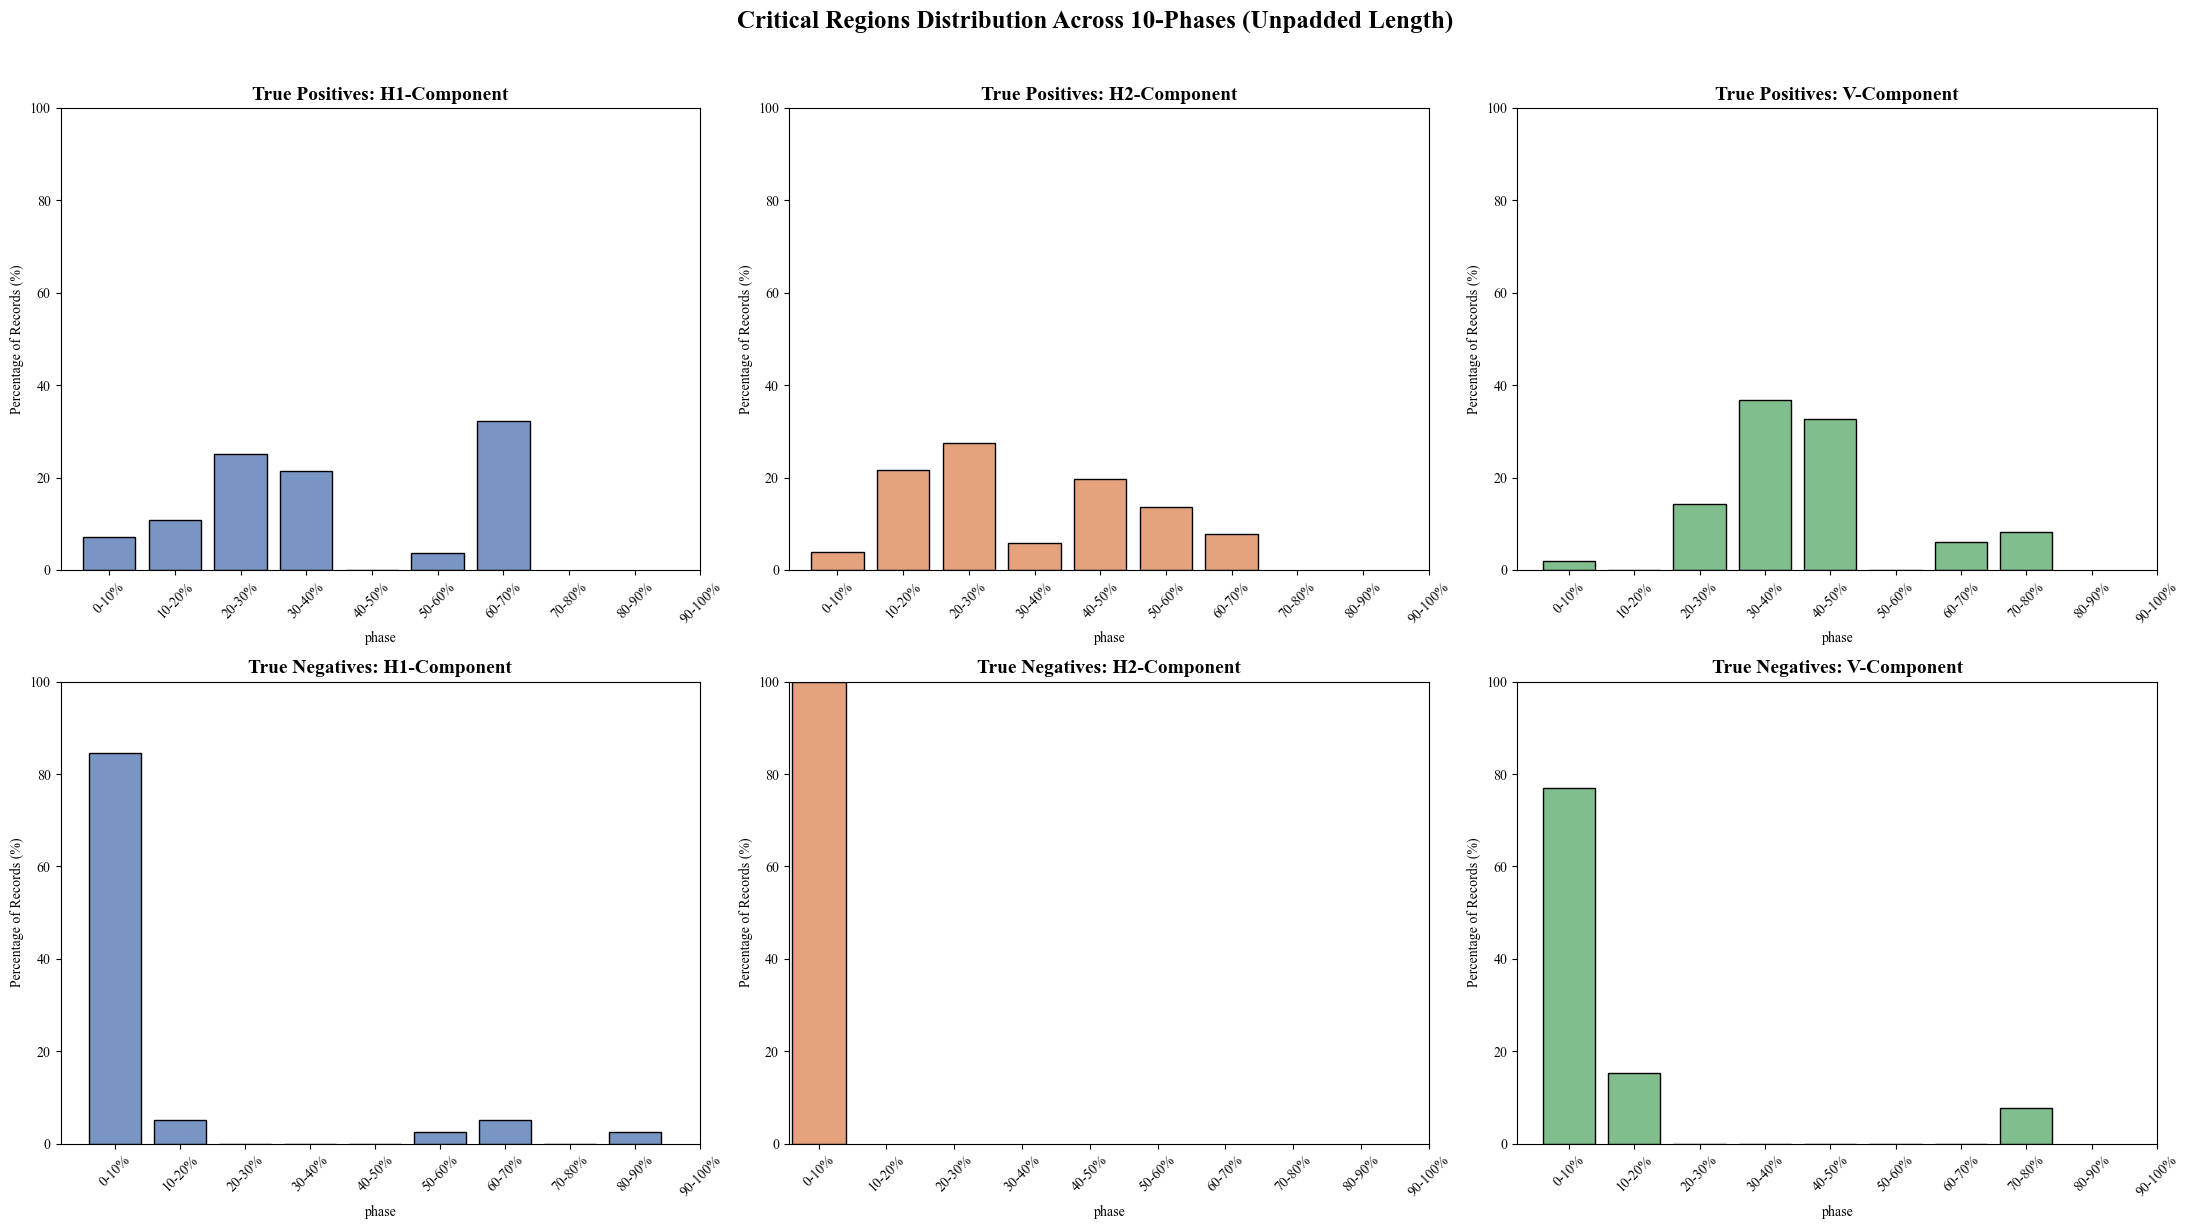

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# =============================================================================
# Step 9: Occlusion Sensitivity Analysis (Unpadded - 10 Phases - TP & TN)
# =============================================================================
print("\n--- Step 9: Running Occlusion Sensitivity Analysis ---")

# Obtain predictions for the entire test dataset
y_pred_probs = model.predict(X_test, batch_size=256).flatten()
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Identify indices for correct predictions (True Positives and True Negatives)
tp_indices = np.where((y_test == 1) & (y_pred_classes == 1))[0]
tn_indices = np.where((y_test == 0) & (y_pred_classes == 0))[0]

print(f"Analyzing {len(tp_indices)} True Positives and {len(tn_indices)} True Negatives...")

def analyze_occlusion_with_df(indices, is_tp=True):
    results = []
    desc = "Processing True Positives (TP)" if is_tp else "Processing True Negatives (TN)"
    
    for idx in tqdm(indices, desc=desc):
        row = xyz_te.iloc[idx]
        original_input = X_test[idx] # Shape: (RECL, 1)
        
        # --- Extract actual signal length (Unpadded) ---
        # Assuming x, y, z components for a single record have equal lengths
        actual_len = len(row['sx']) 
        
        # Define a window size equal to 10% of the actual signal length
        window_size = max(1, int(0.10 * actual_len))
        stride = max(1, window_size // 4)
        
        # Slide the window only across the actual signal portion (pre-zero padding)
        start_positions = np.arange(0, actual_len - window_size + 1, stride)
        if len(start_positions) == 0:
            start_positions = np.array([0])

        # Create a batch of occluded signals for efficient prediction
        occluded_batch = np.tile(original_input, (len(start_positions), 1, 1))
        for i, start in enumerate(start_positions):
            occluded_batch[i, start : start + window_size, 0] = 0

        # Predict scores for all occluded versions in the batch
        occluded_scores = model.predict(occluded_batch, batch_size=512, verbose=0).flatten()
        
        # Identify the critical region (the most influential window)
        if is_tp:
            # For TP: Find the window that causes the maximum drop in probability
            best_idx = np.argmin(occluded_scores) 
        else:
            # For TN: Find the window that causes the maximum increase in error probability
            best_idx = np.argmax(occluded_scores) 
            
        occ_center = start_positions[best_idx] + (window_size // 2)
        
        # Map the critical center to one of 10 equal phases based on actual length
        phase = int(occ_center / (actual_len * 0.10))
        phase = min(phase, 9) # Handle edge cases
        
        results.append({'index': idx, 'phase': phase})
        
    return pd.DataFrame(results)

# Execute the analysis
tp_results = analyze_occlusion_with_df(tp_indices, is_tp=True)
tn_results = analyze_occlusion_with_df(tn_indices, is_tp=False)

# =============================================================================
# Step 10: Visualization by Component (2 Rows x 3 Columns)
# =============================================================================
plt.rcParams['font.family'] = 'Times New Roman'

total_te_len = len(xyz_te)
comp_size = total_te_len // 3
# Renamed components to H1, H2, and V
components = ['H1-Component', 'H2-Component', 'V-Component']
phase_labels = [f'{i*10}-{(i+1)*10}%' for i in range(10)]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

def plot_row(ax_row, df_results, title_prefix):
    for i, comp_name in enumerate(components):
        start_range = i * comp_size
        end_range = (i + 1) * comp_size
        
        # Filter results belonging to the specific component range
        comp_df = df_results[(df_results['index'] >= start_range) & (df_results['index'] < end_range)]
        
        if not comp_df.empty:
            sns.histplot(data=comp_df, x='phase', discrete=True, stat='percent', 
                         shrink=0.8, ax=ax_row[i], color=['#4C72B0', '#DD8452', '#55A868'][i])
            ax_row[i].set_title(f'{title_prefix}: {comp_name}', fontsize=14, fontweight='bold')
            ax_row[i].set_xticks(range(10))
            ax_row[i].set_xticklabels(phase_labels, rotation=45)
            ax_row[i].set_ylim(0, 100)
            ax_row[i].set_ylabel('Percentage of Records (%)')
        else:
            ax_row[i].set_title(f'{title_prefix}: {comp_name}\n(No Data)')

# Plot rows for True Positives and True Negatives
plot_row(axes[0], tp_results, 'True Positives')
plot_row(axes[1], tn_results, 'True Negatives')

plt.suptitle('Critical Regions Distribution Across 10-Phases (Unpadded Length)', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()